<div style="background-color: #f3e5f5; padding: 25px; border-radius: 15px; border: 2px solid #7b1fa2; box-shadow: 2px 2px 8px rgba(0,0,0,0.1); text-align: center; direction: rtl; font-family: 'Vazir', Tahoma, sans-serif;">
<div style="color: #4a148c; font-size: 2em; font-weight: bold; margin-bottom: 8px;">کتاب درک شهودی یادگیری ماشین</div>
<hr style="border: none; border-top: 2px solid #7b1fa2; width: 50%; margin: 12px auto;">
<h2 style="color: #4a148c; margin: 0; font-size: 1.5em; border-bottom: none;">فصل هفتم: بهینه‌سازی فرآیند آموزش</h2>
</div>


<div dir="rtl" align="right">

# مثال عملی مقایسهٔ رگرسیون معمولی و منظم‌سازی

دادهٔ Advertising هزینه‌های تبلیغات و مقدار Sales را دارد. سه مدل خطی معمولی، Ridge و Lasso را مقایسه می‌کنیم. مقدار alpha با اعتبارسنجیِ دادهٔ آموزش انتخاب می‌شود و آزمون تا پایان کنار می‌ماند.

</div>


<div dir="rtl" align="right">

## آماده‌سازی
سلول‌ها را از بالا به پایین اجرا کنید. فایل‌های داده در پوشهٔ `data` قرار دارند. وابستگی‌ها در `requirements.txt` مشخص شده‌اند.

</div>


In [1]:
# آماده‌سازی
%matplotlib inline
from pathlib import Path
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from IPython.display import display

# پوشهٔ داده کنار پوشهٔ نوت‌بوک‌ها قرار دارد.
DATA = Path("../data")
if not DATA.is_dir():
    DATA = Path("data")
if not DATA.is_dir():
    raise FileNotFoundError("Open notebook from the extracted bundle.")
plt.rcParams.update({"figure.figsize": (8, 4), "font.size": 11})

<div dir="rtl" align="right">

## 1. خواندن داده و جداسازی آزمون

سه ستون تبلیغات ورودی و Sales هدف است. واحد Sales در فایل CSV توضیح داده نشده است؛ در خروجی همان واحد فایل را حفظ می‌کنیم.

</div>


In [2]:
# خواندن داده و جداسازی آزمون
from sklearn.model_selection import train_test_split, KFold, GridSearchCV
from sklearn.pipeline import make_pipeline
from sklearn.preprocessing import StandardScaler
from sklearn.linear_model import LinearRegression, Ridge, Lasso
from sklearn.metrics import mean_squared_error

data = pd.read_csv(DATA / "Advertising.csv")
X = data[["TV", "Radio", "Newspaper"]]
y = data["Sales"]
X_train, X_test, y_train, y_test = train_test_split(
    X, y, test_size=0.2, random_state=42)
cv = KFold(n_splits=5, shuffle=True, random_state=42)
print("Train:", len(y_train), "Test:", len(y_test))

Train: 160 Test: 40


<div dir="rtl" align="right">

## 2. انتخاب شدت جریمه در دادهٔ آموزش

استانداردسازی داخل زنجیره قرار دارد تا در هر دور اعتبارسنجی فقط از بخش آموزش همان دور یاد بگیرد. منفی بودن امتیاز داخلی به قرارداد scikit-learn مربوط است؛ برای نمایش MSE علامت را برمی‌گردانیم.

</div>


In [3]:
# انتخاب شدت جریمه در دادهٔ آموزش
models = {"OLS": LinearRegression(), "Ridge": Ridge(),
          "Lasso": Lasso(max_iter=20000)}
searches, rows = {}, []
for name, estimator in models.items():
    pipeline = make_pipeline(StandardScaler(), estimator)
    key = name.lower()
    grid = {} if name == "OLS" else {
        key + "__alpha": np.logspace(-3, 2, 12)}
    search = GridSearchCV(pipeline, grid, cv=cv,
                          scoring="neg_mean_squared_error")
    search.fit(X_train, y_train)
    searches[name] = search
    pred = search.predict(X_test)
    rows.append({"Model": name, "CV MSE": -search.best_score_,
                 "Test MSE": mean_squared_error(y_test, pred),
                 "Parameters": str(search.best_params_)})
display(pd.DataFrame(rows).round(3))

,Model,CV MSE,Test MSE,Parameters
0,OLS,2.879,3.174,{}
1,Ridge,2.879,3.185,{'ridge__alpha': np.float64(0.5336699231206307)}
2,Lasso,2.840,3.185,{'lasso__alpha': np.float64(0.0657933224657568)}


<div dir="rtl" align="right">

## 3. مقایسهٔ ضرایب

ضرایبِ پس از استانداردسازی نمایش داده می‌شوند. Lasso می‌تواند بعضی ضرایب را صفر کند؛ این اتفاق برای هر داده و هر alpha تضمین نمی‌شود.

</div>


,OLS,Ridge,Lasso
TV,3.764,3.752,3.702
Radio,2.792,2.782,2.748
Newspaper,0.056,0.060,0.008


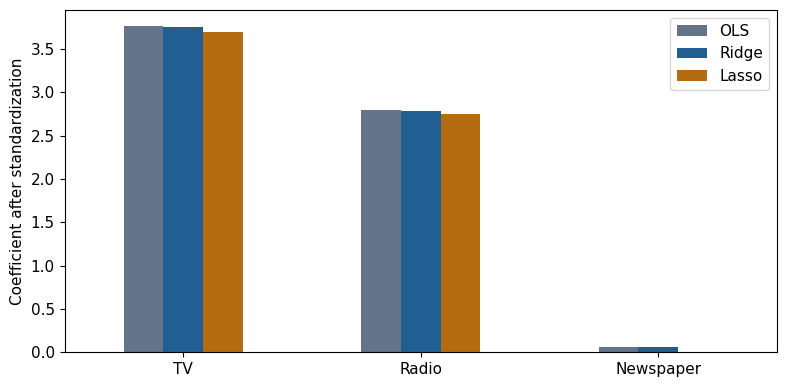

In [4]:
# مقایسهٔ ضرایب
coef = pd.DataFrame({name: search.best_estimator_[-1].coef_
                     for name, search in searches.items()}, index=X.columns)
display(coef.round(3))
coef.plot.bar(color=["#64748b", "#215e91", "#b46b12"])
plt.ylabel("Coefficient after standardization")
plt.xticks(rotation=0)
plt.tight_layout()
plt.show()

<div dir="rtl" align="right">

## نکتهٔ پایانی
در این اجرا، MSE آزمون برای مدل معمولی حدود ۳٫۱۷۴ و برای Ridge و Lasso حدود ۳٫۱۸۵ است. بنابراین منظم‌سازی در این تقسیم، خطای آزمون را کمتر نکرده است. alpha با اعتبارسنجیِ آموزش انتخاب شده؛ آزمون برای انتخاب آن به کار نرفته است.

</div>


<div dir="rtl" align="right">

## مأخذ مثال

مراجع فنی: [scikit-learn](https://scikit-learn.org/1.8/user_guide.html)، [pandas](https://pandas.pydata.org/docs/)، [XGBoost](https://xgboost.readthedocs.io/en/stable/python/python_api.html).

</div>
